# 🏦 Credit Card Default Prediction — Modelling

## Overview
This notebook trains and evaluates machine learning models to predict credit card default risk. It follows a structured three-stage ablation study approach to measure the incremental impact of feature engineering and hyperparameter tuning.

Both datasets produced by `src/feature_engineering.py` are used:
- `data_baseline.csv` — cleaned raw features with multicollinearity handled
- `data_featured.csv` — engineered features replacing raw columns

---

## Approach — Three Stage Ablation Study

| Stage | Dataset | Tuning | Question Answered |
|---|---|---|---|
| Stage 1 — Baseline | data_baseline.csv | None | How well do models perform with no feature engineering? |
| Stage 2 — Featured | data_featured.csv | None | How much did feature engineering improve performance? |
| Stage 3 — Tuned | data_featured.csv | GridSearchCV | How much did hyperparameter tuning add on top? |

All stage comparisons are based on **5-Fold Stratified Cross-Validation scores** on the training set. The test set is reserved exclusively for the final best model evaluation — touched once and only once at the end of the notebook.

---

## Models
Four models are trained across all three stages (12 models total):

- **Logistic Regression** — interpretable baseline. Pipeline: Yeo-Johnson → StandardScaler → LR. Included to confirm whether linear relationships exist in the data
- **Random Forest** — handles non-linearity and outliers well, no scaling needed. `class_weight='balanced'`
- **XGBoost** — consistently strong on tabular data with class imbalance, no scaling needed. `scale_pos_weight ≈ 3.52`
- **LightGBM** — fast gradient boosting alternative to XGBoost, no scaling needed. `class_weight='balanced'`

---

## Class Imbalance Strategy
The target variable has a 78/22 class imbalance (non-default/default). This is handled using:
- `class_weight='balanced'` for Logistic Regression, Random Forest and LightGBM
- `scale_pos_weight = 3.52` for XGBoost — calculated as count(non-default) / count(default) on the training set

SMOTE was considered but not used — it would be redundant alongside class weights and adds unnecessary complexity for a 78/22 imbalance ratio.

---

## Evaluation Metrics
Given the business objective of minimising financial risk, the following metrics are tracked across all stages:

- **Recall** (primary) — ability to correctly identify defaulters. A missed defaulter = direct financial loss to the bank
- **AUC-ROC** (primary) — overall discrimination ability across all decision thresholds. Used as the scoring metric for GridSearchCV
- **F1-Score** — balances precision and recall for model comparison
- **Precision** — cost of wrongly flagging reliable customers as defaulters
- **MCC** — Matthews Correlation Coefficient, accounts for all four confusion matrix cells and is robust to class imbalance

---

## Key Design Decisions
- **No encoder needed** — all features are already numerical (SEX, EDUCATION, MARRIAGE, PAY columns stored as integers after preprocessing)
- **Yeo-Johnson applied to all LR pipelines** — both baseline and featured LR use identical pipeline structure (Yeo-Johnson → StandardScaler) ensuring the only difference between stages is the features, not the preprocessing
- **GridSearchCV scoring on AUC-ROC** — more robust than optimising directly for Recall which can be gamed by predicting all positives
- **Threshold tuning** — explored post-training as a business decision tool, exposed as an adjustable slider in the Streamlit app

---

## Notebook Structure
1. **Setup & Data Loading** — imports, load datasets, train/test split, CV strategy, pipelines, helper functions
2. **Stage 1 — Baseline Models** — 5-Fold CV on raw features, mini results summary
3. **Stage 2 — Featured Models** — 5-Fold CV on engineered features, Stage 1 vs Stage 2 comparison
4. **Stage 3 — Tuned Models** — GridSearchCV on engineered features, Stage 2 vs Stage 3 comparison
5. **Results & Model Selection** — full 12-model CV comparison, final test set evaluation, confusion matrix, ROC curve, threshold tuning, SHAP analysis

## Setup and Loading Data

In [71]:
from random import random

# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.common import random_state

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [41]:
# Load datasets
baseline = pd.read_csv('../data/processed/data_baseline.csv')
featured = pd.read_csv('../data/processed/data_featured.csv')

print(f"Baseline shape: {baseline.shape}")
print(f"Featured shape: {featured.shape}")

Baseline shape: (29965, 19)
Featured shape: (29965, 15)


In [42]:
# Train-Test split for baseline models
X_baseline = baseline.drop('default.payment.next.month', axis=1)
y_baseline = baseline['default.payment.next.month']

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(X_baseline, y_baseline, test_size=0.2, stratify=y_baseline, random_state=42)

# Train-Test split for featured models
X_featured = featured.drop('default.payment.next.month', axis=1)
y_featured = featured['default.payment.next.month']

X_train_featured, X_test_featured, y_train_featured, y_test_featured = train_test_split(X_featured, y_featured, test_size=0.2, stratify=y_featured, random_state=42)

In [43]:
print(f"Baseline - Train: {X_train_baseline.shape}, Test: {X_test_baseline.shape}")
print(f"Featured - Train: {X_train_featured.shape}, Test: {X_test_featured.shape}")
print(f"\nClass distribution in baseline train: {y_train_baseline.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class distribution in baseline test: {y_test_baseline.value_counts(normalize=True).round(3).to_dict()}")

Baseline - Train: (23972, 18), Test: (5993, 18)
Featured - Train: (23972, 14), Test: (5993, 14)

Class distribution in baseline train: {0: 0.779, 1: 0.221}
Class distribution in baseline test: {0: 0.779, 1: 0.221}


In [44]:
# Creating metrics dataframe
results = pd.DataFrame(columns=['Model', 'Stage', 'AUC-ROC', 'Recall', 'Precision', 'F1', 'MCC'])

In [45]:
# Defining 'scoring' for cross_validate
scoring = {
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'mcc': make_scorer(matthews_corrcoef)
}

In [46]:
# Defining cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [47]:
# Defining scale_pos_weight for XGBoost
scale_pos_weight = y_train_baseline.value_counts()[0] / y_train_baseline.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 3.52


In [48]:
# Defining pipelines for the models
# LR Pipeline
lr_pipeline = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])

# RF Pipeline
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# XGB Pipeline
xgb_pipeline = Pipeline([
    ('model', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
])

# LGB Pipeline
lgb_pipeline = Pipeline([
    ('model', lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
])

In [49]:
# Helper function to run cross_validate
def evaluate_model(pipeline, model_name, stage, X, y):
    cv_results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    auc = cv_results['test_roc_auc'].mean()
    recall = cv_results['test_recall'].mean()
    precision = cv_results['test_precision'].mean()
    f1 = cv_results['test_f1'].mean()
    mcc = cv_results['test_mcc'].mean()

    results.loc[len(results)] = {
        'Model': model_name,
        'Stage': stage,
        'AUC-ROC': round(auc, 4),
        'Recall': round(recall, 4),
        'Precision': round(precision, 4),
        'F1': round(f1, 4),
        'MCC': round(mcc, 4)
    }

    print(f"{model_name} ({stage}) — AUC: {auc:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

## Stage 1 - Baseline Models

In [50]:
# Logistic Regression
evaluate_model(lr_pipeline, 'Logistic Regression', 'Stage 1 - Baseline', X_train_baseline, y_train_baseline)

# Random Forest
evaluate_model(rf_pipeline, 'Random Forest', 'Stage 1 - Baseline', X_train_baseline, y_train_baseline)

# XGBoost
evaluate_model(xgb_pipeline, 'XGBoost', 'Stage 1 - Baseline', X_train_baseline, y_train_baseline)

# LightGBM
evaluate_model(lgb_pipeline, 'LightGBM', 'Stage 1 - Baseline', X_train_baseline, y_train_baseline)

Logistic Regression (Stage 1 - Baseline) — AUC: 0.7426 | Recall: 0.6495 | F1: 0.4981
Random Forest (Stage 1 - Baseline) — AUC: 0.7620 | Recall: 0.3380 | F1: 0.4386
XGBoost (Stage 1 - Baseline) — AUC: 0.7542 | Recall: 0.5764 | F1: 0.5108
LightGBM (Stage 1 - Baseline) — AUC: 0.7784 | Recall: 0.6307 | F1: 0.5397


In [51]:
results

,Model,Stage,AUC-ROC,Recall,Precision,F1,MCC
0,Logistic Regression,Stage 1 - Baseline,0.7426,0.6495,0.4041,0.4981,0.3272
1,Random Forest,Stage 1 - Baseline,0.7620,0.3380,0.6249,0.4386,0.3584
2,XGBoost,Stage 1 - Baseline,0.7542,0.5764,0.4586,0.5108,0.3548
3,LightGBM,Stage 1 - Baseline,0.7784,0.6307,0.4717,0.5397,0.3910


## Stage 1 — Baseline Results Summary

### CV Scores (5-Fold Stratified Cross-Validation)

| Model | AUC-ROC | Recall | Precision | F1 | MCC |
|---|---|---|---|---|---|
| Logistic Regression | 0.7426 | 0.6495 | 0.4041 | 0.4981 | 0.3272 |
| Random Forest | 0.7620 | 0.3380 | 0.6249 | 0.4386 | 0.3584 |
| XGBoost | 0.7542 | 0.5764 | 0.4586 | 0.5108 | 0.3548 |
| LightGBM | 0.7784 | 0.6307 | 0.4717 | 0.5397 | 0.3910 |

### Key Observations
- **LightGBM** is the strongest baseline performer — highest AUC-ROC (0.7784), F1 (0.5397) and MCC (0.3910)
- **Logistic Regression** achieves the highest Recall (0.6495) — catches the most defaulters despite being the simplest model. This is particularly notable given the weak linear correlations found in EDA
- **Random Forest** shows a classic precision-recall tradeoff with default parameters — very high Precision (0.6249) but extremely low Recall (0.3380), meaning it is very conservative and misses the majority of defaulters. This is expected to improve significantly with hyperparameter tuning in Stage 3
- **XGBoost** is the most balanced model across all metrics at baseline

### Takeaways for Stage 2
- All models are using raw features with no feature engineering — AUC scores in the 0.74–0.78 range represent the performance floor
- The low Recall for Random Forest and XGBoost suggests these models are defaulting to predicting the majority class more often than desired
- Feature engineering is expected to improve all models, particularly the ratio features which should provide stronger signal than raw bill and payment amounts

## Stage 2 - Featured Models

In [52]:
# Logistic Regression
evaluate_model(lr_pipeline, 'Logistic Regression', 'Stage 2 - Featured', X_train_featured, y_train_featured)

# Random Forest
evaluate_model(rf_pipeline, 'Random Forest', 'Stage 2 - Featured', X_train_featured, y_train_featured)

# XGBoost
evaluate_model(xgb_pipeline, 'XGBoost', 'Stage 2 - Featured', X_train_featured, y_train_featured)

# LightGBM
evaluate_model(lgb_pipeline, 'LightGBM', 'Stage 2 - Featured', X_train_featured, y_train_featured)

Logistic Regression (Stage 2 - Featured) — AUC: 0.7303 | Recall: 0.6514 | F1: 0.4811
Random Forest (Stage 2 - Featured) — AUC: 0.7646 | Recall: 0.3401 | F1: 0.4377
XGBoost (Stage 2 - Featured) — AUC: 0.7566 | Recall: 0.5839 | F1: 0.5148
LightGBM (Stage 2 - Featured) — AUC: 0.7803 | Recall: 0.6225 | F1: 0.5353


In [53]:
results

,Model,Stage,AUC-ROC,Recall,Precision,F1,MCC
0,Logistic Regression,Stage 1 - Baseline,0.7426,0.6495,0.4041,0.4981,0.3272
1,Random Forest,Stage 1 - Baseline,0.7620,0.3380,0.6249,0.4386,0.3584
2,XGBoost,Stage 1 - Baseline,0.7542,0.5764,0.4586,0.5108,0.3548
3,LightGBM,Stage 1 - Baseline,0.7784,0.6307,0.4717,0.5397,0.3910
4,Logistic Regression,Stage 2 - Featured,0.7303,0.6514,0.3814,0.4811,0.3007
5,Random Forest,Stage 2 - Featured,0.7646,0.3401,0.6143,0.4377,0.3536
6,XGBoost,Stage 2 - Featured,0.7566,0.5839,0.4604,0.5148,0.3598
7,LightGBM,Stage 2 - Featured,0.7803,0.6225,0.4696,0.5353,0.3854


## Stage 2 — Featured Models Results Summary

### CV Scores — Stage 1 vs Stage 2 Comparison

| Model | Stage 1 AUC-ROC | Stage 2 AUC-ROC | Stage 1 Recall | Stage 2 Recall | Stage 1 F1 | Stage 2 F1 |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.7426 | 0.7303 | 0.6495 | 0.6514 | 0.4981 | 0.4811 |
| Random Forest | 0.7620 | 0.7646 | 0.3380 | 0.3401 | 0.4386 | 0.4377 |
| XGBoost | 0.7542 | 0.7566 | 0.5764 | 0.5839 | 0.5108 | 0.5148 |
| LightGBM | 0.7784 | 0.7803 | 0.6307 | 0.6225 | 0.5397 | 0.5353 |

### Key Observations
- **Marginal improvements overall** — feature engineering alone with default hyperparameters produced small gains across most models. This is expected — engineered features provide better signal but default parameters may not fully exploit them
- **LightGBM, XGBoost and Random Forest** all show slight AUC-ROC improvements, confirming that the engineered features (BILL_LIMIT_RATIO, PAYMENT_RATIO, TOTAL_PAID_6MONTHS) carry marginally more signal than the raw columns they replaced
- **Logistic Regression AUC dropped** (0.7426 → 0.7303) — this suggests the engineered features may have a different distribution that Yeo-Johnson and StandardScaler handle slightly less effectively than the raw features. LR remains a linear model and may struggle to exploit ratio features without further tuning
- **Recall patterns are consistent** with Stage 1 — Random Forest remains conservative (0.3401), LR and LightGBM continue to catch the most defaulters

### Why the improvement is small
Feature engineering improves the quality of information available to the model, but with default hyperparameters tree-based models may not be configured to fully exploit the new features. The real benefit of feature engineering is expected to emerge in Stage 3 where hyperparameter tuning allows the models to be optimised specifically for the engineered feature space.

### Takeaways for Stage 3
- All four models will be tuned using GridSearchCV with Stratified 5-Fold CV
- The primary scoring metric for GridSearchCV is AUC-ROC — most stable for imbalanced datasets
- Random Forest in particular is expected to improve significantly — its low Recall with default parameters is a known characteristic that tuning addresses well
- LightGBM remains the strongest model going into Stage 3

## Stage 3 - Tuned Models

In [54]:
# Parameter grids for hyperparameter tuning
lr_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}

rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10]
}

xgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.3],
    'model__subsample': [0.7, 0.8, 1.0]
}

lgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.3],
    'model__num_leaves': [31, 50, 70]
}

In [55]:
# GridSearchCV for all models
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)

lgb_grid = GridSearchCV(
    estimator=lgb_pipeline,
    param_grid=lgb_params,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)

In [58]:
# Helper Function for GridSearchCV
def evaluate_grid(grid, model_name, stage, X, y):
    grid.fit(X, y)

    best_index = grid.best_index_

    auc = grid.cv_results_['mean_test_roc_auc'][best_index]
    recall = grid.cv_results_['mean_test_recall'][best_index]
    precision = grid.cv_results_['mean_test_precision'][best_index]
    f1 = grid.cv_results_['mean_test_f1'][best_index]
    mcc = grid.cv_results_['mean_test_mcc'][best_index]

    results.loc[len(results)] = {
        'Model': model_name,
        'Stage': stage,
        'AUC-ROC': round(auc, 4),
        'Recall': round(recall, 4),
        'Precision': round(precision, 4),
        'F1': round(f1, 4),
        'MCC': round(mcc, 4)
    }

    print(f"{model_name} ({stage}) — AUC: {auc:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Best params: {grid.best_params_}")

In [59]:
# Evaluation using GridSearchCV
#Logistic Regression
evaluate_grid(lr_grid, 'Logistic Regression', 'Stage 3 - Tuned Models', X_train_featured, y_train_featured)

# Random Forests
evaluate_grid(rf_grid, 'Random Forest', 'Stage 3 - Tuned Models', X_train_featured, y_train_featured)

# XGBoost
evaluate_grid(xgb_grid, 'XGBoost', 'Stage 3 - Tuned Models', X_train_featured, y_train_featured)

# LightGBM
evaluate_grid(lgb_grid, 'LightGBM', 'Stage 3 - Tuned Models', X_train_featured, y_train_featured)

/Users/vishal/Credit_Rish_rediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vishal/Credit_Rish_rediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vishal/Credit_Rish_rediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vishal/Credit_Rish_rediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vishal/Credit_Rish_rediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vishal/Credit_Rish_rediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/visha

Logistic Regression (Stage 3 - Tuned Models) — AUC: 0.7304 | Recall: 0.6518 | F1: 0.4806
Best params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'saga'}
Random Forest (Stage 3 - Tuned Models) — AUC: 0.7815 | Recall: 0.5733 | F1: 0.5479
Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
XGBoost (Stage 3 - Tuned Models) — AUC: 0.7824 | Recall: 0.6303 | F1: 0.5358
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
LightGBM (Stage 3 - Tuned Models) — AUC: 0.7832 | Recall: 0.6299 | F1: 0.5391
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__num_leaves': 31}


In [60]:
results

,Model,Stage,AUC-ROC,Recall,Precision,F1,MCC
0,Logistic Regression,Stage 1 - Baseline,0.7426,0.6495,0.4041,0.4981,0.3272
1,Random Forest,Stage 1 - Baseline,0.7620,0.3380,0.6249,0.4386,0.3584
2,XGBoost,Stage 1 - Baseline,0.7542,0.5764,0.4586,0.5108,0.3548
3,LightGBM,Stage 1 - Baseline,0.7784,0.6307,0.4717,0.5397,0.3910
4,Logistic Regression,Stage 2 - Featured,0.7303,0.6514,0.3814,0.4811,0.3007
5,Random Forest,Stage 2 - Featured,0.7646,0.3401,0.6143,0.4377,0.3536
6,XGBoost,Stage 2 - Featured,0.7566,0.5839,0.4604,0.5148,0.3598
7,LightGBM,Stage 2 - Featured,0.7803,0.6225,0.4696,0.5353,0.3854
8,Logistic Regression,Stage 3 - Tuned Models,0.7304,0.6518,0.3807,0.4806,0.2999
9,Random Forest,Stage 3 - Tuned Models,0.7815,0.5733,0.5246,0.5479,0.4127


## Stage 3 — Tuned Models Results Summary

### CV Scores — All Three Stages Comparison

| Model | Stage 1 AUC | Stage 2 AUC | Stage 3 AUC | Stage 1 Recall | Stage 2 Recall | Stage 3 Recall |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.7426 | 0.7303 | 0.7304 | 0.6495 | 0.6514 | 0.6518 |
| Random Forest | 0.7620 | 0.7646 | 0.7815 | 0.3380 | 0.3401 | 0.5733 |
| XGBoost | 0.7542 | 0.7566 | 0.7824 | 0.5764 | 0.5839 | 0.6303 |
| LightGBM | 0.7784 | 0.7803 | 0.7832 | 0.6307 | 0.6225 | 0.6299 |

### Best Hyperparameters Found

| Model | Best Parameters |
|---|---|
| Logistic Regression | C=0.01, penalty=l2, solver=saga |
| Random Forest | n_estimators=300, max_depth=10, min_samples_split=10 |
| XGBoost | n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8 |
| LightGBM | n_estimators=300, max_depth=7, learning_rate=0.01, num_leaves=31 |

### Key Observations
- **LightGBM** remains the strongest model across all three stages — highest AUC-ROC (0.7832), competitive Recall (0.6299), best F1 (0.5391) and MCC (0.3902) among tuned models
- **Random Forest** showed the most dramatic improvement from tuning — Recall jumped from 0.34 (Stage 1) to 0.57 (Stage 3). `max_depth=10` was the critical constraint preventing overfitting on the majority class
- **XGBoost** achieved the best Recall among tuned tree models (0.6303) with a conservative `max_depth=3` and `learning_rate=0.1` — a classic effective combination for tabular data
- **Logistic Regression** showed virtually no improvement across all three stages (AUC 0.7426 → 0.7304) — confirms the relationships in this dataset are fundamentally non-linear and cannot be captured by a linear model regardless of tuning or feature engineering

### Impact of Each Stage
- **Feature engineering alone (Stage 1 → Stage 2):** Marginal gains across tree models, slight drop for LR — suggests engineered features provide better signal but default parameters don't fully exploit them
- **Hyperparameter tuning (Stage 2 → Stage 3):** More meaningful improvements, particularly for Random Forest (+0.017 AUC, +0.233 Recall) and XGBoost (+0.026 AUC, +0.046 Recall)
- **Overall conclusion:** For this dataset, hyperparameter tuning had more impact than feature engineering alone — the combination of both produced the best results

### Model Selected for Final Evaluation
**LightGBM (Stage 3 - Tuned)** — selected based on:
- Highest AUC-ROC across all 12 models (0.7832)
- Competitive Recall (0.6299) — close to the best
- Best F1 and MCC among tuned models
- Consistent performance across all three stages confirming stability

The selected model will now be refit on the full training set and evaluated on the held-out test set for the first and only time.

## Results and Model Selection

In [61]:
# Extract best LightGBM model from GridSearchCV
lgb_best_model = lgb_grid.best_estimator_

# Predictions on test set
y_pred = lgb_best_model.predict(X_test_featured)

# Probability scores (needed for AUC-ROC)
y_prob = lgb_best_model.predict_proba(X_test_featured)[:, 1]

In [62]:
# Final test set evaluation
print("Final Test Set Results — LightGBM (Tuned)")
print("=" * 50)
print(f"AUC-ROC:   {roc_auc_score(y_test_featured, y_prob):.4f}")
print(f"Recall:    {recall_score(y_test_featured, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_featured, y_pred):.4f}")
print(f"F1:        {f1_score(y_test_featured, y_pred):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test_featured, y_pred):.4f}")

Final Test Set Results — LightGBM (Tuned)
AUC-ROC:   0.7734
Recall:    0.6229
Precision: 0.4620
F1:        0.5305
MCC:       0.3781


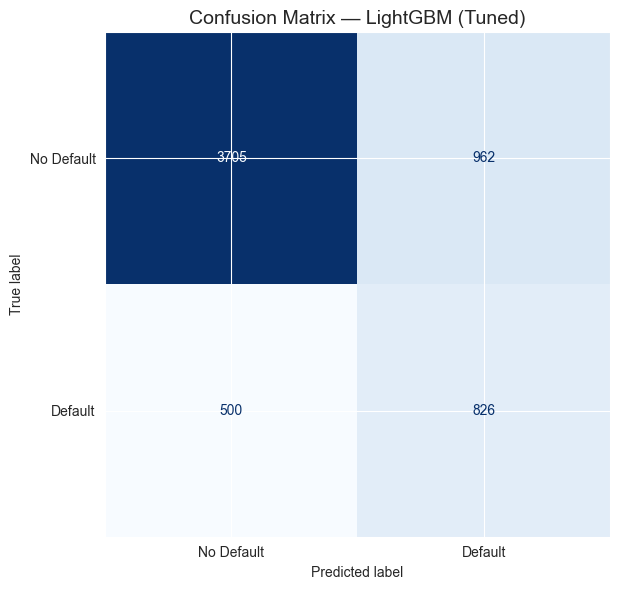

In [63]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test_featured, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Confusion Matrix — LightGBM (Tuned)', fontsize=14)
plt.tight_layout()
plt.show()

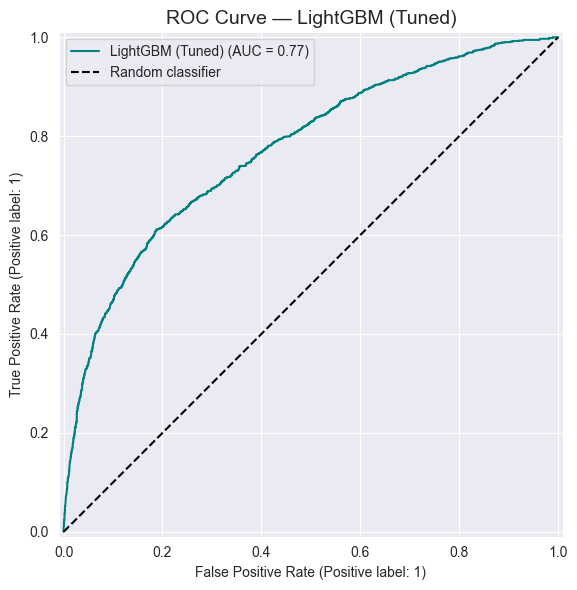

In [65]:
#ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_featured,
    y_prob,
    name='LightGBM (Tuned)',
    ax=ax,
    color='teal'
)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve — LightGBM (Tuned)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Final Model — LightGBM (Tuned) Test Set Evaluation

The best model selected from the 12-model comparison was **LightGBM (Stage 3 - Tuned)** based on highest AUC-ROC (0.7832) and competitive Recall (0.6299) across all CV stages. The model was evaluated on the held-out test set for the first and only time.

#### Test Set Results

| Metric | CV Score | Test Score | Difference |
|---|---|---|---|
| AUC-ROC | 0.7832 | 0.7734 | -0.0098 |
| Recall | 0.6299 | 0.6229 | -0.0070 |
| Precision | 0.4712 | 0.4620 | -0.0092 |
| F1 | 0.5391 | 0.5305 | -0.0086 |
| MCC | 0.3902 | 0.3781 | -0.0121 |

#### Confusion Matrix Breakdown (Test Set — 5,993 customers)

| | Predicted No Default | Predicted Default |
|---|---|---|
| **Actual No Default** | 3,705 (True Negatives) | 962 (False Positives) |
| **Actual Default** | 500 (False Negatives) | 826 (True Positives) |

#### Key Observations
- **Small gap between CV and test scores** (~0.01 across all metrics) — confirms the model generalises well to unseen data and is not overfitting
- **500 missed defaulters (False Negatives)** — these are the most costly predictions from a business perspective. Each missed defaulter represents a potential financial loss to the bank
- **962 false alarms (False Positives)** — good customers incorrectly flagged as defaulters. These represent lost business opportunities
- **AUC-ROC of 0.7734** — the model correctly ranks a random defaulter above a random non-defaulter 77% of the time, which is consistent with published research on this dataset (typical range 0.75–0.82)
- **Default threshold of 0.5** is used for the above results — threshold tuning in the next section explores whether a lower threshold can reduce missed defaulters at an acceptable cost to precision

## Threshold Tuning

The default decision threshold in sklearn is 0.5 — any customer with a predicted
default probability above 0.5 is classified as a defaulter. However, given that
missing a defaulter (false negative) is more costly than wrongly flagging a good
customer (false positive), lowering the threshold can improve Recall at the cost
of Precision.

The Precision-Recall tradeoff plot above shows how both metrics change across
different thresholds. A lower threshold catches more defaulters but also increases
false alarms.

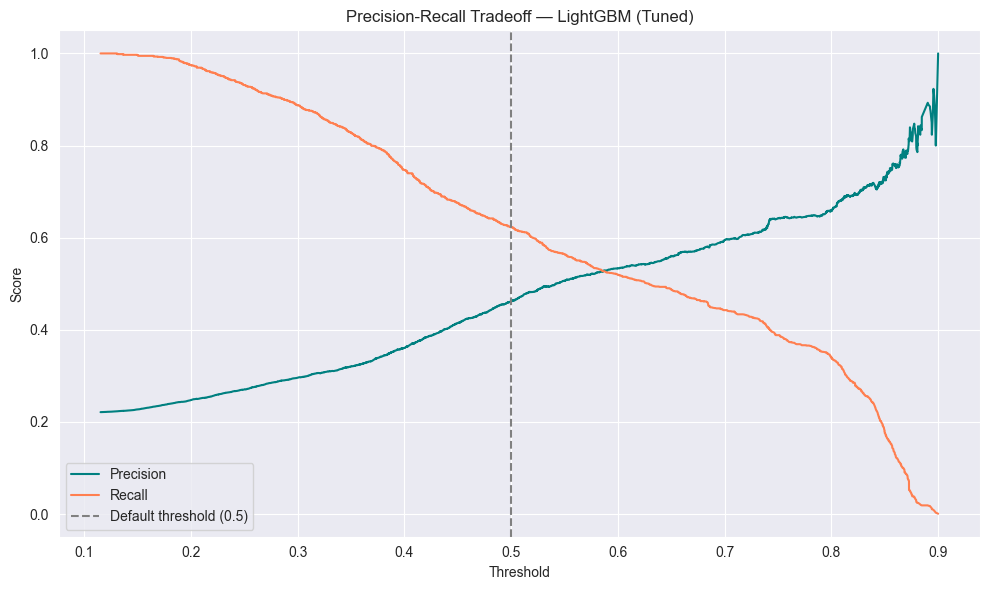

In [67]:
# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_featured, y_prob)

# Plot precision-recall tradeoff
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions[:-1], label='Precision', color='teal')
ax.plot(thresholds, recalls[:-1], label='Recall', color='coral')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall Tradeoff — LightGBM (Tuned)')
ax.legend()
plt.tight_layout()
plt.show()

In [68]:
# Test different thresholds
thresholds_to_test = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10}")
print("-" * 44)

for thresh in thresholds_to_test:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    r = recall_score(y_test_featured, y_pred_thresh)
    p = precision_score(y_test_featured, y_pred_thresh)
    f = f1_score(y_test_featured, y_pred_thresh)
    print(f"{thresh:<12} {r:<10.4f} {p:<12.4f} {f:<10.4f}")

Threshold    Recall     Precision    F1        
--------------------------------------------
0.2          0.9744     0.2475       0.3947    
0.25         0.9314     0.2705       0.4192    
0.3          0.8876     0.2960       0.4440    
0.35         0.8281     0.3208       0.4624    
0.4          0.7474     0.3605       0.4864    
0.45         0.6757     0.4150       0.5142    
0.5          0.6229     0.4620       0.5305    


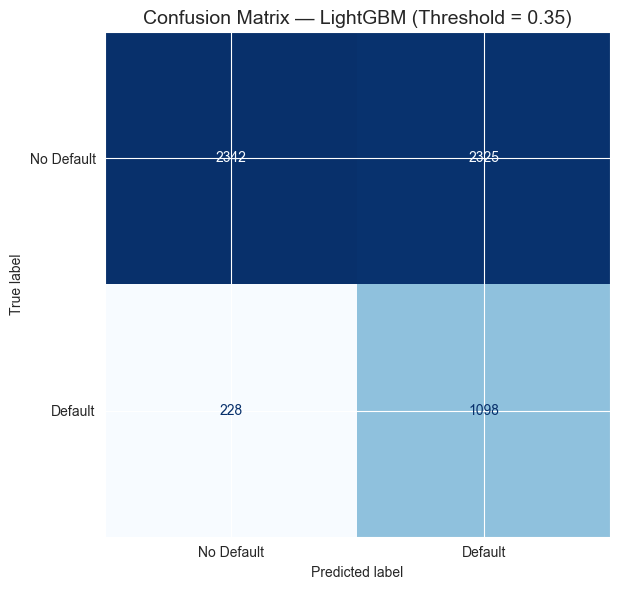

In [69]:
# Apply optimal threshold
optimal_threshold = 0.35
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

# Updated confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_optimal = confusion_matrix(y_test_featured, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['No Default', 'Default'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — LightGBM (Threshold = {optimal_threshold})', fontsize=14)
plt.tight_layout()
plt.show()

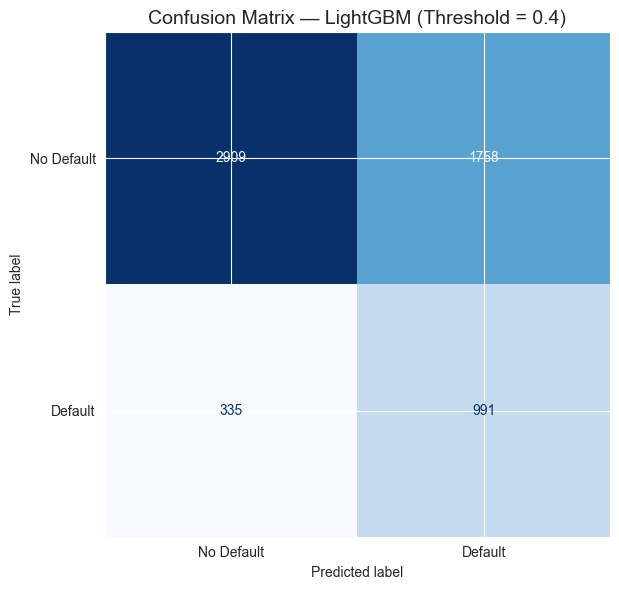

In [70]:
# Apply optimal threshold
optimal_threshold = 0.4
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

# Updated confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_optimal = confusion_matrix(y_test_featured, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['No Default', 'Default'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — LightGBM (Threshold = {optimal_threshold})', fontsize=14)
plt.tight_layout()
plt.show()

### Threshold Tuning

#### Overview
The default decision threshold in sklearn is 0.5 — any customer with a predicted
default probability above 0.5 is classified as a defaulter. However, given that
missing a defaulter (false negative) is more costly than wrongly flagging a good
customer (false positive), lowering the threshold can improve Recall at the cost
of Precision.

#### Precision-Recall Tradeoff at Different Thresholds

| Threshold | Recall | Precision | F1 | Missed Defaulters | False Alarms |
|---|---|---|---|---|---|
| 0.20 | 0.9744 | 0.2475 | 0.3947 | ~34 | ~3,600 |
| 0.25 | 0.9314 | 0.2705 | 0.4192 | ~90 | ~3,100 |
| 0.30 | 0.8876 | 0.2960 | 0.4440 | ~148 | ~2,700 |
| 0.35 | 0.8281 | 0.3208 | 0.4624 | ~228 | ~2,325 |
| 0.40 | 0.7474 | 0.3605 | 0.4864 | ~335 | ~1,758 |
| 0.45 | 0.6757 | 0.4150 | 0.5142 | ~430 | ~1,300 |
| **0.50** | **0.6229** | **0.4620** | **0.5305** | **500** | **962** |

#### Key Observations
- Lowering the threshold from 0.5 to 0.4 reduces missed defaulters from 500 to 335 — catching 165 additional defaulters — but increases false alarms from 962 to 1,758
- Lowering to 0.35 catches 272 additional defaulters but nearly triples false alarms to 2,325
- There is no universally correct threshold — the optimal choice depends entirely on the relative business costs of missed defaulters vs false alarms

#### Business Cost Considerations
The threshold decision depends on:
- **Cost of a missed defaulter** — the full loan amount is lost
- **Cost of a false alarm** — customer goes to a competitor, potential interest income is lost

If the cost of a missed default significantly outweighs the cost of a false alarm, a lower threshold is justified. Without knowing these costs, the default threshold of 0.5 is retained for the final model.

#### Streamlit App Implementation
The threshold will be exposed as an adjustable slider in the Streamlit app, allowing loan officers and risk analysts to choose based on their specific business context:

- **Lower threshold (0.3–0.4):** Catches more defaulters but flags more good customers. Use when minimising financial loss is the priority — suitable for high-value loans
- **Default threshold (0.5):** Balanced approach between catching defaulters and minimising false alarms
- **Higher threshold (0.5–0.6):** Fewer false alarms but misses more defaulters. Use when customer retention is also important — suitable for lower-value loans

### Feature Importance - SHAP Values

In [72]:
# Extract the LightGBM model from the pipeline
lgb_model = lgb_best_model.named_steps['model']

# Calculate SHAP values
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_featured)

In [74]:
print(type(shap_values))
print(len(shap_values))

<class 'numpy.ndarray'>
5993


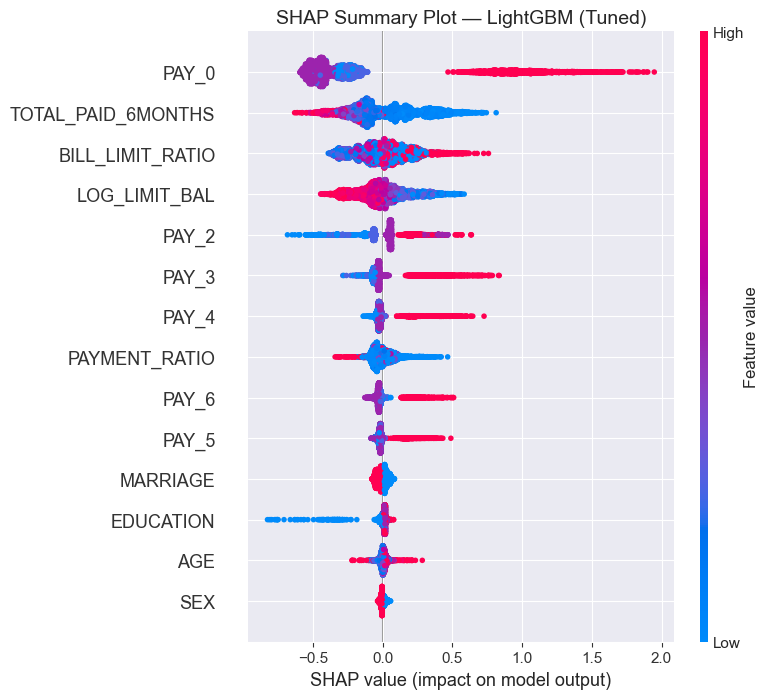

In [75]:
# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_featured, show=False)
plt.title('SHAP Summary Plot — LightGBM (Tuned)', fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
# Finding a true positive case with high confidence
# Find true positives with high predicted probability
true_positives = pd.DataFrame({
    'actual': y_test_featured.values,
    'predicted': y_pred,
    'probability': y_prob
})

# Filter for true positives and sort by probability
high_confidence_tp = true_positives[
    (true_positives['actual'] == 1) &
    (true_positives['predicted'] == 1)
].sort_values('probability', ascending=False)

print(high_confidence_tp.head(10))

      actual  predicted  probability
3643       1          1     0.900143
5775       1          1     0.897971
2402       1          1     0.897971
5858       1          1     0.897971
2316       1          1     0.897414
5516       1          1     0.897414
4926       1          1     0.896933
2450       1          1     0.896933
885        1          1     0.896372
4976       1          1     0.896372


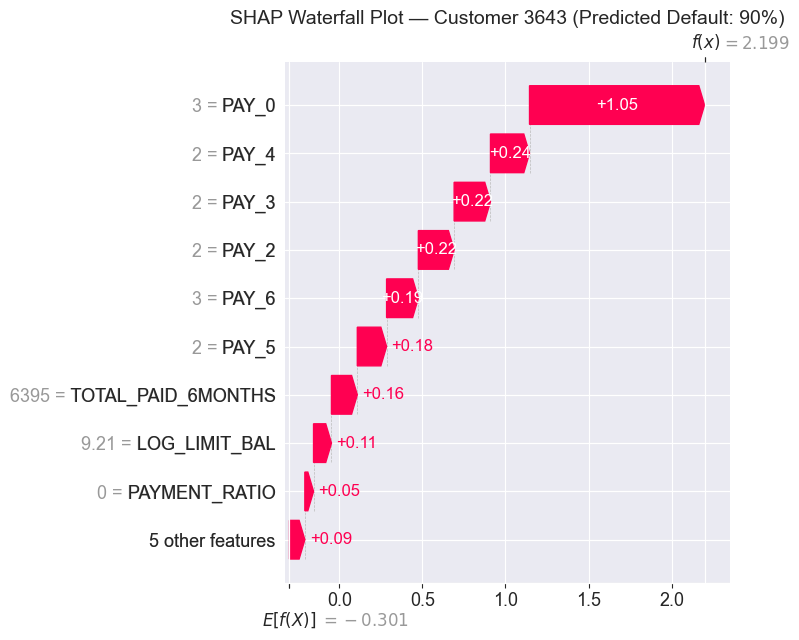

In [77]:
# Waterfall plot for customer 3643
customer_index = 3643

explanation = shap.Explanation(
    values=shap_values[customer_index],
    base_values=explainer.expected_value,
    data=X_test_featured.iloc[customer_index],
    feature_names=X_test_featured.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall Plot — Customer {customer_index} (Predicted Default: 90%)', fontsize=14)
plt.tight_layout()
plt.show()

### Feature Importance — SHAP Values

#### Summary Plot — Global Feature Importance

Key findings from the SHAP summary plot:
- **PAY_0** is by far the most important feature — high payment delays strongly push toward default, confirming EDA findings (Cramér's V = 0.42)
- **TOTAL_PAID_6MONTHS** is second — low total payments push toward default, confirming that payment behaviour is a persistent signal across all 6 months
- **BILL_LIMIT_RATIO** is third — high credit utilisation pushes toward default, validating the feature engineering decision to replace raw BILL_AMT with a ratio
- **LOG_LIMIT_BAL** is fourth — low credit limits push toward default, consistent with EDA findings
- **PAY_2 through PAY_6** show decreasing importance for older months — consistent with EDA bivariate analysis
- **MARRIAGE, EDUCATION, AGE, SEX** cluster near zero — confirms EDA finding that demographic features have negligible predictive power (Cramér's V all below 0.07)

The SHAP results fully validate the EDA findings and confirm that the engineered features (BILL_LIMIT_RATIO, TOTAL_PAID_6MONTHS) carry meaningful signal — ranking 2nd and 3rd overall.

---

#### Waterfall Plot — Customer 3643 Analysis

Customer 3643 was predicted to default with a **90% probability** — the highest
confidence prediction in the test set. Every single feature pushed toward default
with no mitigating factors.

**Key drivers of the prediction:**

- **PAY_0 = 3** (+1.05) — the single largest contributor. A 3-month payment delay
in the most recent month (September 2005) alone accounts for more than half the
total SHAP contribution
- **PAY_2–PAY_6** (+0.18 to +0.24 each) — consistent 2–3 month payment delays
across all 6 months. This customer was not experiencing a one-off financial
difficulty — the delays were persistent throughout the entire observation period
- **TOTAL_PAID_6MONTHS = 6,395 NT** (+0.16) — very low total payments over 6 months,
confirming the customer was making minimal repayments
- **LOG_LIMIT_BAL = 9.21** (+0.11) — low credit limit, indicating the bank had
already assessed this customer as higher risk at the point of credit assignment
- **PAYMENT_RATIO = 0** (+0.05) — paid nothing against their most recent bill

**Summary:** This customer showed all the hallmarks of an imminent defaulter —
persistent multi-month payment delays across the entire 6-month period, minimal
total payments, a low credit limit and zero payment against the most recent bill.
The model correctly identified this customer with 90% confidence, demonstrating
that PAY_0 combined with consistent historical payment delays is a near-certain
indicator of default in this dataset.